Using cuda device


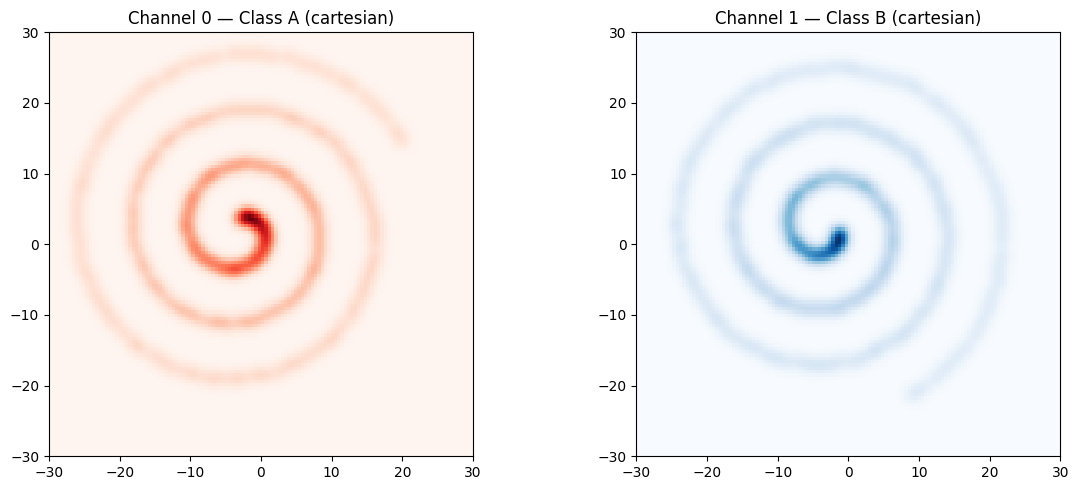

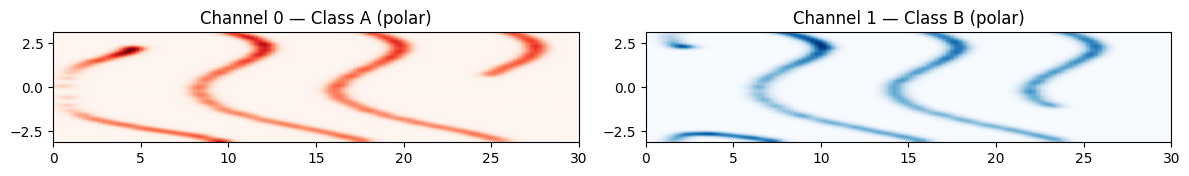

  → best 0.5051  epoch=0
  → best 0.1414  epoch=1
  → best 0.0101  epoch=2
  → best 0.0000  epoch=4
Early stop.
Saved to Conv_Cart_conv.npz


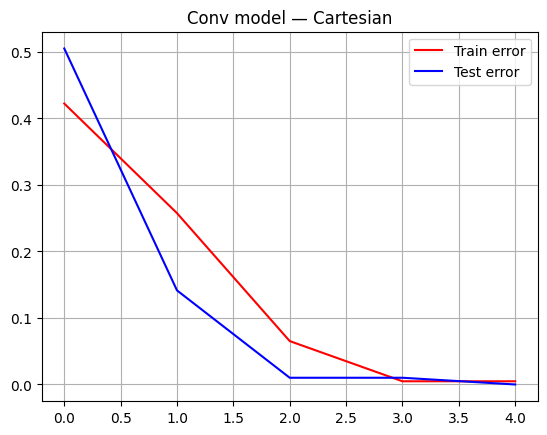

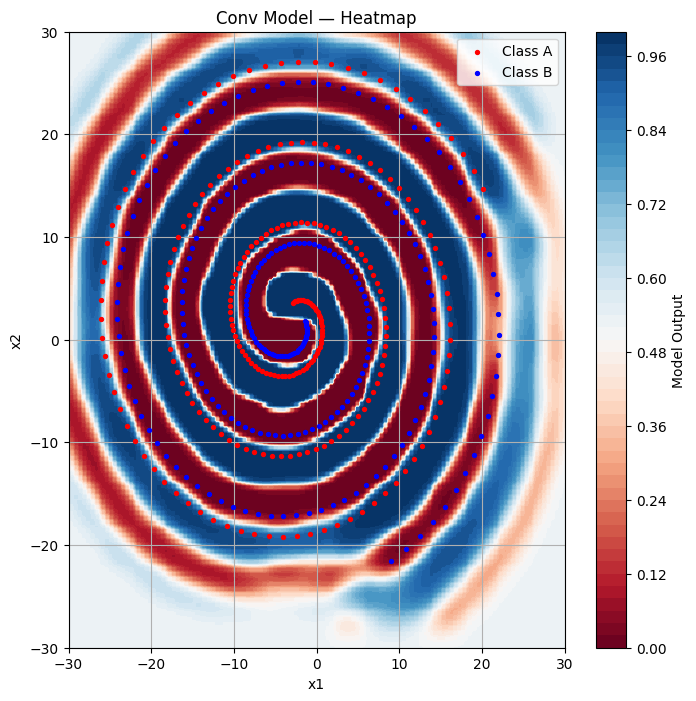

  → best 0.0303  epoch=0
  → best 0.0000  epoch=1
Early stop.
Saved to Conv_Polar_conv.npz


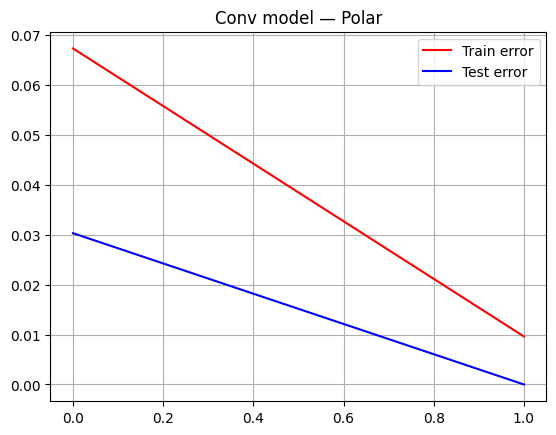

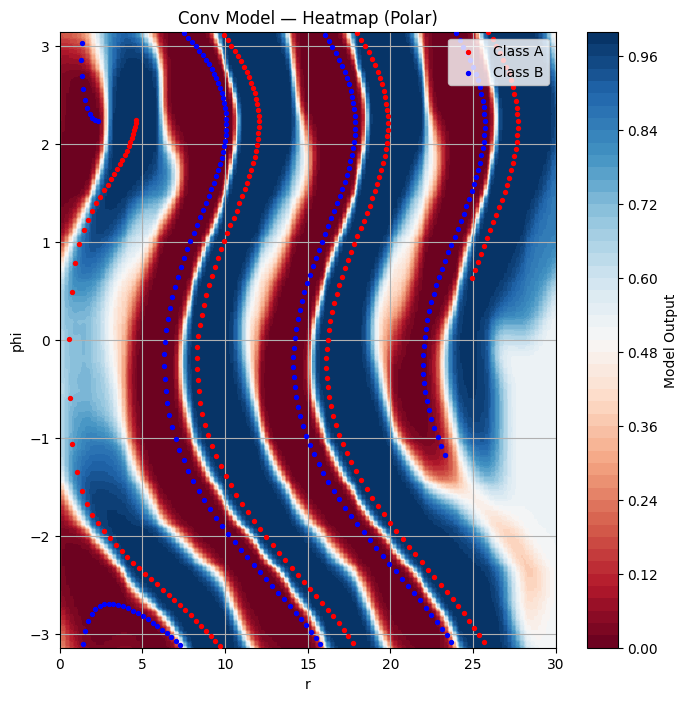

In [ ]:
import torch
from torch import nn
from torch.utils.data import random_split, TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.serialization.add_safe_globals([np._core.multiarray.scalar])

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# =============================================================================
# Data Generation
# =============================================================================

def gen_class_A():
    u = np.arange(1, 250)
    x = -3.0 + 0.1 * np.sin(0.08 * u) * (u + 15)
    y = 2 + 0.1 * np.cos(0.08 * u) * (u + 15)
    labels = np.ones(len(u))
    return np.column_stack([x, y, labels])

def gen_class_B():
    u = np.arange(1, 250)
    x = -3.0 + 0.1 * np.sin(0.08 * u + 1.6) * (u + 15)
    y = 2 + 0.1 * np.cos(0.08 * u + 1.6) * (u + 15)
    labels = np.zeros(len(u))
    return np.column_stack([x, y, labels])

A = gen_class_A()
B = gen_class_B()

spiral_A = torch.Tensor(A)
spiral_B = torch.Tensor(B)

GRID_SIZE = 128          # pixels along each axis
PATCH     =  32          # patch side length (must be even)
SIGMA_PX  =   2.0        # Gaussian blur sigma in pixels

# Cartesian axis bounds
CART_MIN = -30.0
CART_MAX =  30.0

# Polar axis bounds  — axis 0: r, axis 1: phi
POLAR_R_MIN   =  0.0
POLAR_R_MAX   = 30.0
POLAR_PHI_MIN = -np.pi
POLAR_PHI_MAX =  np.pi

def world_to_pixel(coords, axis0_min, axis0_max, axis1_min, axis1_max,
                   grid_size=GRID_SIZE):
    """
    Map world coordinates to pixel indices (float).
    coords: (N, 2) array where column 0 → horizontal axis (col),
                                   column 1 → vertical axis (row).
    """
    col = (coords[:, 0] - axis0_min) / (axis0_max - axis0_min) * (grid_size - 1)
    row = (coords[:, 1] - axis1_min) / (axis1_max - axis1_min) * (grid_size - 1)
    return np.column_stack([col, row])

def make_density_map(points_xy, axis0_min, axis0_max, axis1_min, axis1_max,
                     grid_size=GRID_SIZE, sigma=SIGMA_PX):
    """
    Rasterise (N, 2) world-coordinate points onto a grid_size×grid_size
    occupancy map with a Gaussian blur for smooth gradients.
    Returns a numpy array of shape (grid_size, grid_size).
    """
    from scipy.ndimage import gaussian_filter
    grid = np.zeros((grid_size, grid_size), dtype=np.float32)
    px = world_to_pixel(points_xy, axis0_min, axis0_max, axis1_min, axis1_max,
                        grid_size)
    for col, row in px:
        c, r = int(round(col)), int(round(row))
        if 0 <= r < grid_size and 0 <= c < grid_size:
            grid[r, c] += 1.0
    grid = gaussian_filter(grid, sigma=sigma)
    if grid.max() > 0:
        grid /= grid.max()
    return grid

def make_padded_map(points_A, points_B, axis0_min, axis0_max, axis1_min, axis1_max):
    """Build a padded 2-channel density map for one coordinate space."""
    half = PATCH // 2
    ch0 = make_density_map(points_A, axis0_min, axis0_max, axis1_min, axis1_max)
    ch1 = make_density_map(points_B, axis0_min, axis0_max, axis1_min, axis1_max)
    gmap = np.stack([ch0, ch1], axis=0)                              # (2, G, G)
    padded = np.pad(gmap, ((0, 0), (half, half), (half, half)),
                    mode='constant', constant_values=0.0)
    return gmap, padded

def extract_patch(px_col, px_row, padded):
    """Extract a (2, PATCH, PATCH) patch centred at pixel (px_col, px_row)."""
    half = PATCH // 2
    r = int(round(px_row)) + half
    c = int(round(px_col)) + half
    return padded[:, r - half:r + half, c - half:c + half].copy()

def make_conv_dataset(points_A, points_B, axis0_min, axis0_max, axis1_min, axis1_max):
    """
    Build a TensorDataset of (2, PATCH, PATCH) patches and labels for any
    2D coordinate space defined by the given axis bounds.
    Returns: dataset, global_map, padded_map
    """
    gmap, padded = make_padded_map(points_A, points_B,
                                   axis0_min, axis0_max, axis1_min, axis1_max)
    all_points = np.vstack([points_A, points_B])   # (N, 3)
    px_coords  = world_to_pixel(all_points[:, :2],
                                axis0_min, axis0_max, axis1_min, axis1_max)
    patches, labels = [], []
    for point, px in zip(all_points, px_coords):
        patches.append(extract_patch(px[0], px[1], padded))
        labels.append(point[2])

    patches_t = torch.tensor(np.stack(patches), dtype=torch.float32)
    labels_t  = torch.tensor(labels,            dtype=torch.float32)
    return TensorDataset(patches_t, labels_t), gmap, padded

def transform_to_polar(x1, x2):
    r   = np.sqrt(x1**2 + x2**2)
    phi = np.arctan2(x2, x1)
    return r, phi

# --- Cartesian dataset ---
dataset_conv, global_map_cart, padded_map_cart = make_conv_dataset(
    A, B, CART_MIN, CART_MAX, CART_MIN, CART_MAX
)

# --- Polar dataset ---
r_A, phi_A = transform_to_polar(A[:, 0], A[:, 1])
r_B, phi_B = transform_to_polar(B[:, 0], B[:, 1])
A_polar = np.column_stack([r_A, phi_A, np.ones(len(A))])
B_polar = np.column_stack([r_B, phi_B, np.zeros(len(B))])

dataset_conv_polar, global_map_polar, padded_map_polar = make_conv_dataset(
    A_polar, B_polar, POLAR_R_MIN, POLAR_R_MAX, POLAR_PHI_MIN, POLAR_PHI_MAX
)

generator = torch.Generator().manual_seed(42)

train_set_conv, test_set_conv = random_split(dataset_conv, [0.8, 0.2],
                                              generator=generator)
train_loader_conv = DataLoader(train_set_conv, batch_size=32, shuffle=True)
test_loader_conv  = DataLoader(test_set_conv,  batch_size=32, shuffle=False)

train_set_conv_polar, test_set_conv_polar = random_split(dataset_conv_polar, [0.8, 0.2],
                                                          generator=generator)
train_loader_conv_polar = DataLoader(train_set_conv_polar, batch_size=32, shuffle=True)
test_loader_conv_polar  = DataLoader(test_set_conv_polar,  batch_size=32, shuffle=False)

# =============================================================================
# Visualise the global map (sanity check)
# =============================================================================

def plot_global_map(gmap, title_a, title_b, extent):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(gmap[0], origin='lower', extent=extent, cmap='Reds')
    axes[0].set_title(title_a)
    axes[1].imshow(gmap[1], origin='lower', extent=extent, cmap='Blues')
    axes[1].set_title(title_b)
    plt.tight_layout()
    plt.show()


class SpiralClassifierConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),   # (2,32,32)  → (16,32,32)
            nn.ReLU(),
            nn.MaxPool2d(2),                               #            → (16,16,16)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  #            → (32,16,16)
            nn.ReLU(),
            nn.MaxPool2d(2),                               #            → (32, 8, 8)
            nn.Flatten(),                                  #            → 2048
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.stack(x)


def save_results(model, error_y, test_error_y, label):
    filename = f"{label}_conv.npz"
    np.savez(filename, train_error=error_y, test_error=test_error_y)
    print(f"Saved to {filename}")

def training_run(train, model, lossfn, optimizer):
    model.train()
    run_error = []
    optimizer.zero_grad()

    for datapoint, label in train:
        datapoint = datapoint.to(device)
        label     = label.to(device)

        noisy = datapoint + torch.randn_like(datapoint) * 0.06

        prediction = model(noisy)
        loss = lossfn(prediction, label.float().unsqueeze(1))

        # Measure error on clean input so train/test curves are comparable
        with torch.no_grad():
            clean_pred = model(datapoint)
            predicted_classes = (clean_pred >= 0.5).float().squeeze(1)
            wrong_count = (predicted_classes != label).type(torch.float).mean().item()
        run_error.append(wrong_count)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    return np.average(run_error)

def training_loop(training_data, test_data, model, lossfn, learning_rate,
                  epochs, label: str):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    error_hist    = []
    test_err_hist = []
    best_test_err = np.inf

    for epoch in range(epochs):
        current_run_err  = training_run(training_data, model, lossfn, optimizer)
        error_hist.append(current_run_err)

        current_test_err = test_run(test_data, model, lossfn)
        test_err_hist.append(current_test_err)

        if current_test_err < best_test_err:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': current_run_err,
            }, f"BestModelSpiral_{label}.pth")
            best_test_err = current_test_err
            print(f"  → best {best_test_err:.4f}  epoch={epoch}")
            if best_test_err < 0.01:
                print("Early stop.")
                break

    return np.array(error_hist), np.array(test_err_hist)

def test_run(test_data, model, lossfn):
    total_wrong   = 0
    total_samples = 0
    model.eval()
    with torch.no_grad():
        for datapoint, label in test_data:
            datapoint = datapoint.to(device)
            label     = label.to(device)
            prediction = model(datapoint)
            predicted_classes = (prediction >= 0.5).float().squeeze(1)
            total_wrong   += (predicted_classes != label).sum().item()
            total_samples += label.size(0)
    return total_wrong / total_samples

# =============================================================================
# Heatmap helpers
# =============================================================================

def _grid_to_patches(range0, range1, padded_map_to_use, axis0_min, axis0_max,
                     axis1_min, axis1_max):
    """
    Shared helper: convert a meshgrid of world coordinates into a batch of
    (2, PATCH, PATCH) patches drawn from the given padded density map.
    Returns (xx, yy, patches_tensor_on_device).
    """
    xx, yy     = np.meshgrid(range0, range1)
    grid_world = np.column_stack([xx.ravel(), yy.ravel()])           # (M, 2)
    grid_px    = world_to_pixel(grid_world,
                                axis0_min, axis0_max, axis1_min, axis1_max)

    patches = [extract_patch(px[0], px[1], padded_map_to_use) for px in grid_px]
    patches_t = torch.tensor(np.stack(patches), dtype=torch.float32).to(device)
    return xx, yy, patches_t

def _run_model_on_patches(model, patches_t, out_shape, chunk=512):
    """Run model on a large patch tensor in chunks; return output reshaped to out_shape."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(patches_t), chunk):
            preds.append(model(patches_t[i:i + chunk]).squeeze(1).cpu().numpy())
    return np.concatenate(preds).reshape(out_shape)

# --- Cartesian heatmap (matches plot_heatmap signature exactly) ---
def plot_heatmap(x_range, y_range, model):
    xx, yy, patches_t = _grid_to_patches(
        x_range, y_range, padded_map_cart,
        CART_MIN, CART_MAX, CART_MIN, CART_MAX
    )
    z = _run_model_on_patches(model, patches_t, xx.shape)

    plt.figure(figsize=(8, 8))
    plt.contourf(xx, yy, z, levels=50, cmap='RdBu')
    plt.colorbar(label='Model Output')
    plt.scatter(A[:, 0], A[:, 1], c='red',  s=8, label='Class A', zorder=3)
    plt.scatter(B[:, 0], B[:, 1], c='blue', s=8, label='Class B', zorder=3)
    plt.legend(loc='upper right')
    plt.grid()
    plt.title('Conv Model — Heatmap')
    plt.xlabel('x1'); plt.ylabel('x2')
    plt.show()

# --- Polar heatmap (matches plot_heatmap_polar signature exactly) ---
def plot_heatmap_polar(r_range, phi_range, model):
    rr, pp, patches_t = _grid_to_patches(
        r_range, phi_range, padded_map_polar,
        POLAR_R_MIN, POLAR_R_MAX, POLAR_PHI_MIN, POLAR_PHI_MAX
    )
    z = _run_model_on_patches(model, patches_t, rr.shape)

    plt.figure(figsize=(8, 8))
    plt.contourf(rr, pp, z, levels=50, cmap='RdBu')
    plt.colorbar(label='Model Output')
    plt.scatter(r_A, phi_A, c='red',  s=8, label='Class A', zorder=3)
    plt.scatter(r_B, phi_B, c='blue', s=8, label='Class B', zorder=3)
    plt.legend(loc='upper right')
    plt.xlabel('r'); plt.ylabel('phi')
    plt.grid()
    plt.title('Conv Model — Heatmap (Polar)')
    plt.show()

# =============================================================================
# Runs
# =============================================================================

lossfn = nn.BCELoss()

# Sanity-check the density maps
plot_global_map(global_map_cart,
                'Channel 0 — Class A (cartesian)', 'Channel 1 — Class B (cartesian)',
                extent=[CART_MIN, CART_MAX, CART_MIN, CART_MAX])
plot_global_map(global_map_polar,
                'Channel 0 — Class A (polar)', 'Channel 1 — Class B (polar)',
                extent=[POLAR_R_MIN, POLAR_R_MAX, POLAR_PHI_MIN, POLAR_PHI_MAX])

x1_range  = np.linspace(CART_MIN,      CART_MAX,      int(60 / 0.25))
x2_range  = np.linspace(CART_MIN,      CART_MAX,      int(60 / 0.25))
r_range   = np.linspace(POLAR_R_MIN,   POLAR_R_MAX,   int(60 / 0.25))
phi_range = np.linspace(POLAR_PHI_MIN, POLAR_PHI_MAX, int(60 / 0.25))

# --- Cartesian ---
model_conv_cart = SpiralClassifierConv().to(device)
error_y, test_error_y = training_loop(
    train_loader_conv, test_loader_conv, model_conv_cart, lossfn, 0.001, 1000, "Conv_Cart"
)
save_results(model_conv_cart, error_y, test_error_y, "Conv_Cart")

plt.plot(error_y,      color="r", label="Train error")
plt.plot(test_error_y, color="b", label="Test error")
plt.grid(); plt.legend(loc="upper right")
plt.title("Conv model — Cartesian"); plt.show()

plot_heatmap(x1_range, x2_range, model_conv_cart)

# --- Polar ---
model_conv_polar = SpiralClassifierConv().to(device)
error_y, test_error_y = training_loop(
    train_loader_conv_polar, test_loader_conv_polar, model_conv_polar, lossfn, 0.001, 1000, "Conv_Polar"
)
save_results(model_conv_polar, error_y, test_error_y, "Conv_Polar")

plt.plot(error_y,      color="r", label="Train error")
plt.plot(test_error_y, color="b", label="Test error")
plt.grid(); plt.legend(loc="upper right")
plt.title("Conv model — Polar"); plt.show()

plot_heatmap_polar(r_range, phi_range, model_conv_polar)